- I will presented on April 29 after Madison.  Number 3 presenter for the evening.  Seems ideal.

- top priorities:

    -  finish acm report

    - finish powerpoint

- load indivdual datasets
- examine datasets and experiment
- what graphs and charts will be useful?
- I like my two graphics.  What else can I visualize?
- what other interesting research questions can I ask? The correlation of genre or production company to flop seemed bunk. I think partly because my data is junky

- clean up data
    - already cleaned up the credits csv
    - fill n/a for blank or values that are zero ie. revenue or budget
    - clear out junk data from is_adult column
    - maybe create a whole separate file for cleaning / pre-processing
    - do i need to drop duplicates?  I noticed at least one duplicate movie.

- Guidelines for Project Specification

- Data Description
- Research Questions

- Data Analysis
    - Overall Summary
    - Group Analysis
    - Time Series
    - Visualization of Distributions
    - Time series visualization
    - Other visualizations

- what ML techniques should I use?
    - Need at least one Unsupervised task
    - Need at least one Supervised task

- notes from Dr. Gruppi:
```Great!

Try to keep in mind strategies to handle missing/garbage data. For instance, will you drop rows that contain poor-quality data?

Your list probably has a lage number of actors. Regarding your last question -- do actors _guarantee_ the success of the film or do they simply __correlate__ with success? That is, if a high profile actor is cast in a movie, chances are that the whole production is also huge, this includes advertising and media presence. Just some food for thought! Remember: correlation does not mean causation!
```

```Todo:

- create powerpoint
- make sure that I am crystal clear on the code in my slideshow
- create acm styled report (8 page max)
- write a meaningful readme, describe files included and any instructions
- drop dupes
- Unsupervised task
- Supervised task
    - word embedding / svm.  genre prediction ?
- move clean movie text code to clean_final_project file
- pitfalls
```

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

movies_df = pd.read_csv("Datasets/clean_movies.csv")
cast_df = pd.read_csv("Datasets/clean_cast.csv")
crew_df = pd.read_csv("Datasets/clean_crew.csv")
keyword_df = pd.read_csv("Datasets/clean_keyword.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
production_df = pd.read_csv("Datasets/clean_production.csv")



In [144]:
#inspect the cleaned data

data_frames = {
    "movies_df": movies_df,
    "cast_df": cast_df,
    "crew_df": crew_df,
    "keyword_df": keyword_df,
    "genres_df": genres_df,
    "production_df": production_df
}

for name, df in data_frames.items():
    print(f"\n" + "*"*55)
    print(f" {name} Head")
    print("*"*55)
    print(df.head())
    
    print(f"\n" + "*"*55)
    print(f" {name} Info")
    print("*"*55)
    df.info()
    print("*"*55)



*******************************************************
 movies_df Head
*******************************************************
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toysto

In [145]:
#create derived value -> profit

movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
# profit_avg = movies_df['profit'].mean().round(2)
# pop_avg = movies_df['popularity'].mean()

# print(f"The average profit from this collection is ${profit_avg}")
# print(f"The average popularity from this collection is {pop_avg}")

# under_movies_df = movies_df[(movies_df['profit'] < profit_avg) & (movies_df['popularity'] < pop_avg)]


In [146]:
#What constitutes a flop or a low performing film?

#Is it popularity?  

#Drop any row with popularity = 0 and with vote counts less than 15.  This will eliminate blanks and films with low vote counts.

movies_df = movies_df[(movies_df['popularity'] != 0)& (movies_df['vote_count'] > 15)]

#List the top 100 least popular movies

least_popular = movies_df.sort_values('popularity').head(100)

least_popular[['original_title', 'popularity']]

,original_title,popularity
13559,Land des Schweigens und der Dunkelheit,0.000220
34233,Elephant,0.000578
9942,Parenti serpenti,0.000844
11570,7 Plus Seven,0.001021
41170,Eccezzziunale... veramente,0.002538
...,...,...
16822,Nijushi no hitomi,0.617717
15587,अमर अकबर एन्थोनी,0.618416
25302,Nativity 2: Danger in the Manger!,0.619534
18754,Like Water,0.621056


In [147]:
#From this top 100 list what are the agreed upon least popular films?
#i am not going to use this anymore.  especially since i just realized that popularity and user rating are different :(

# most_unpop = least_popular.sort_values(by=['popularity', 'vote_count'],ascending=[True, False]).head(100)

# most_unpop[['original_title', 'popularity', 'vote_count']]

In [148]:
#low user rating
movies_df = movies_df[(movies_df['vote_average'] != 0)& (movies_df['vote_count'] > 50)]

#List the top 100 lowest rated movies

low_rating = movies_df.sort_values('vote_average').head(100)

low_rating[['original_title', 'vote_average']]

,original_title,vote_average
8620,Manos: The Hands of Fate,2.0
17745,Birdemic: Shock and Terror,2.1
6734,House of the Dead,2.8
40563,Back in the Day,2.8
30816,The Hottie & The Nottie,2.9
...,...,...
36454,The Abandoned,4.1
14784,Stan Helsing,4.1
36646,Norm of the North,4.1
1490,Speed 2: Cruise Control,4.1


In [150]:
#Is a flop a film that lost money?

#drop any film with budget or revenue equal to 0 to eliminate noise

movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]
movies_df.sort_values('revenue').head(100)



,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,keywords,movie_text,profit
23184,False,NaN,1500000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,138222,tt1885300,en,Best Man Down,A newlywed couple cancels their honeymoon and ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Best Man Down,False,6.1,65.0,[],comedy drama a newlywed couple cancels their h...,-1498062.0
20252,False,NaN,12000000,"[{'id': 53, 'name': 'Thriller'}]",http://www.thesamaritanfilm.com/,98339,tt1867093,en,The Samaritan,"After twenty years in prison, Foley is finishe...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,The Samaritan,False,5.2,69.0,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...",thriller prison sex revenge incest grifter pat...,-11997479.0
20935,False,NaN,2500000,"[{'id': 18, 'name': 'Drama'}]",NaN,94901,tt1945062,en,About Cherry,A drama centered on a troubled young woman who...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,There's No Such Thing As Going Too Far.,About Cherry,False,4.4,91.0,"[{'id': 445, 'name': 'pornography'}]",drama there s no such thing as going too far. ...,-2496997.0
19381,False,NaN,3000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",NaN,89691,tt1603257,en,ATM,"On a late night visit to an ATM, three co-work...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,No warning. No control. No escape.,ATM,False,5.1,195.0,"[{'id': 157145, 'name': 'atm'}, {'id': 157146,...",horror thriller no warning. no control. no esc...,-2996990.0
44216,False,NaN,10500000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name...",NaN,390051,tt4581576,en,Aftermath,A fatal plane crash changes the lives of Roman...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,All he had left was revenge,Aftermath,False,5.8,162.0,"[{'id': 822, 'name': 'airport'}, {'id': 894, '...",drama thriller all he had left was revenge air...,-10496549.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23618,False,NaN,4141459,"[{'id': 18, 'name': 'Drama'}]",http://diaphana.fr/film/17-filles,87368,tt1860152,fr,17 filles,Inspired by events that took place in Massachu...,...,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,17 Girls,False,5.6,103.0,"[{'id': 187056, 'name': 'woman director'}]",drama woman director inspired by events that t...,-3939852.0
16949,False,NaN,12000000,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name...",NaN,53172,tt1220888,en,Henry's Crime,An aimless man is sent to prison for a crime h...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The real crime is not committing to your dreams.,Henry's Crime,False,5.8,110.0,"[{'id': 5569, 'name': 'vomit'}, {'id': 10960, ...",crime comedy the real crime is not committing ...,-11795060.0
8952,False,NaN,2500000,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",NaN,27274,tt0099611,en,Frankenhooker,A medical school dropout loses his fiancée in ...,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A terrifying tale of sluts and bolts.,Frankenhooker,False,5.7,65.0,"[{'id': 293, 'name': 'female nudity'}, {'id': ...",comedy horror science fiction a terrifying tal...,-2294932.0
10820,False,NaN,4750000,"[{'id': 14, 'name': 'Fantasy'}, {'id': 27, 'na...",http://www.tamaramovie.com/,10263,tt0401815,en,Tamara,"Tamara, an unattractive girl who is picked on ...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Revenge has a killer body.,Tamara,False,5.1,64.0,"[{'id': 3133, 'name': 'vampire'}, {'id': 3737,...",fantasy horror thriller revenge has a killer b...,-4543129.0


In [151]:
#Figure out what the mean profit/popularity is
profit_avg = movies_df['profit'].mean().round(2)
pop_avg = movies_df['popularity'].mean().round(2)
pop_std = round(movies_df['popularity'].std(), 2)
profit_std = round(movies_df['profit'].std(), 2)
pop_top = movies_df.loc[movies_df['popularity'].idxmax()]
rating_top = movies_df.loc[movies_df['vote_average'].idxmax()]
profit_top = movies_df.loc[movies_df['profit'].idxmax()]
pop_top_title = pop_top['original_title']
pop_top_am = pop_top['popularity']
rat_top_title = rating_top['original_title']
rat_top_am = rating_top['vote_average']
pro_top_title = profit_top['original_title']
pro_top_am = profit_top['profit']


print(f"The average profit from this collection is ${profit_avg}")
print(f"The average popularity from this collection is {pop_avg}")
print(f"The standard deviation of profit from this collection is ${profit_std}")
print(f"The standard deviation of popularity from this collection is {pop_std}")
print(f"The most popular movie was {pop_top_title} with a rating of {pop_top_am}")
print(f"The most highest rated movie was {rat_top_title} with a rating of {rat_top_am}")
print(f"The most profitable movie was {pro_top_title} with a total of ${pro_top_am}")


The average profit from this collection is $73107058.49
The average popularity from this collection is 11.42
The standard deviation of profit from this collection is $151880435.03
The standard deviation of popularity from this collection is 14.8
The most popular movie was Minions with a rating of 547.488298
The most highest rated movie was Dilwale Dulhania Le Jayenge with a rating of 9.1
The most profitable movie was Avatar with a total of $2550965087.0


In [152]:
#Sort films that are not profitable, least profitable first.

print("These are the least profitable films.")

least_profitable = movies_df.sort_values('profit').head(100)
least_profitable[['original_title', 'budget', 'revenue', 'profit', 'popularity']]

These are the least profitable films.


,original_title,budget,revenue,profit,popularity
21217,The Lone Ranger,255000000,89289910.0,-165710090.0,12.729104
7237,The Alamo,145000000,25819961.0,-119180039.0,12.240901
16824,Mars Needs Moms,150000000,38992758.0,-111007242.0,7.247170
45347,Valerian and the City of a Thousand Planets,197471676,90024292.0,-107447384.0,15.262706
2716,The 13th Warrior,160000000,61698899.0,-98301101.0,10.308026
...,...,...,...,...,...
6398,Sinbad: Legend of the Seven Seas,60000000,26288320.0,-33711680.0,8.388773
18707,The Big Year,41000000,7448385.0,-33551615.0,10.267905
543,Terminal Velocity,50000000,16478900.0,-33521100.0,8.012225
4972,Baby's Day Out,50000000,16671505.0,-33328495.0,12.508518


In [153]:
#Are there any films that are in the top 500 least popular and top 500 least profitable?

least_popular= movies_df.sort_values('popularity').head(500)
least_profitable = movies_df.sort_values('profit').head(500)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

print("And the bigest losers are...")
print(f"There are {len(overlap)} movies that are in both top 500 least popular and least profitable lists.")      
overlap[['original_title', 'budget', 'revenue', 'popularity', 'profit']]

And the bigest losers are...
There are 86 movies that are in both top 500 least popular and least profitable lists.


,original_title,budget,revenue,popularity,profit
20973,The Internship,58000000,44000000.0,0.393865,-14000000.0
3971,Cherry 2000,10000000,14000.0,2.849779,-9986000.0
9293,特務迷城,25697387,3849941.0,3.136813,-21847446.0
19064,5 Days of War,20000000,17479.0,3.174512,-19982521.0
22291,The Nutcracker: The Untold Story,90000000,16178959.0,3.394928,-73821041.0
...,...,...,...,...,...
18103,The Double,17000000,3696232.0,5.498819,-13303768.0
4613,Summer Catch,34000000,19693891.0,5.499867,-14306109.0
3018,The Bonfire of the Vanities,47000000,15691192.0,5.507082,-31308808.0
16477,The Warrior's Way,42000000,11087569.0,5.510805,-30912431.0


In [154]:
#And now from the overlap, what are the agreed upon least popular and least profitable films

rotten_tomato = overlap.sort_values(by=['profit', 'popularity', 'vote_count'],ascending=[True, True, False]).head(100)

rotten_tomato[['original_title', 'profit', 'popularity', 'vote_count']]

,original_title,profit,popularity,vote_count
3078,Supernova,-75171919.0,5.496624,109.0
9367,A Sound of Thunder,-74010360.0,4.980191,111.0
22291,The Nutcracker: The Untold Story,-73821041.0,3.394928,52.0
16320,How Do You Know,-71331093.0,5.458387,229.0
12033,The Invasion,-64928486.0,5.228837,366.0
...,...,...,...,...
14863,Ondine,-10355245.0,4.757269,84.0
1353,Marvin's Room,-10196695.0,5.307984,130.0
21752,Metallica: Through the Never,-10027033.0,5.229975,86.0
21075,Forces spéciales,-9989241.0,5.358400,132.0


In [155]:
# example for the powerpoint
# #create derived value -> profit
# movies_df['profit'] = movies_df['revenue'] - movies_df['budget']

# #Drop any row with popularity = 0 and with vote counts less than 100.  
# # This will eliminate blanks and films with low vote counts.
# movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 100)]

# #sort by least popular and display
# least_popular = movies_df.sort_values('popularity').head(100)
# least_popular[['original_title', 'popularity', 'vote_count']]

# #drop any film with budget or revenue less than $500 to eliminate noise
# movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

# #Are there any films that are in the top 500 least popular and top 500 least profitable?
# least_popular= movies_df.sort_values('popularity').head(500)
# least_profitable = movies_df.sort_values('profit').head(500)
# overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

# #What are the agreed upon least popular and least profitable films? Sort by profit, popularity and then vote count.
# rotten_tomato = overlap.sort_values(by=['profit', 'popularity', 'vote_count'],ascending=[True, True, False]).head(100)
# rotten_tomato[['original_title', 'profit', 'popularity', 'vote_count']]



In [156]:
#widening the overlap to get more potential matches:

least_popular= movies_df.sort_values('popularity').head(1000)
least_profitable = movies_df.sort_values('profit').head(1000)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

#Now let's identify cast and crew that are involved in flops

cast_overlap = pd.merge(overlap, cast_df, left_on='id', right_on='movie_id')
crew_overlap = pd.merge(overlap, crew_df, left_on='id', right_on='movie_id')

print(cast_overlap[['title', 'actor_name', 'character']])
print(crew_overlap[['title', 'crew_name', 'job', 'department']])


                   title               actor_name  \
0              Manhunter         William Petersen   
1              Manhunter               Kim Greist   
2              Manhunter            Dennis Farina   
3              Manhunter                Brian Cox   
4              Manhunter               Joan Allen   
...                  ...                      ...   
6730  Out of the Furnace  Tiffany Sander McKenzie   
6731  Out of the Furnace            Phil Nardozzi   
6732  Out of the Furnace              James Quinn   
6733  Out of the Furnace              Brenna Roth   
6734  Out of the Furnace              Aaron Toney   

                                          character  
0                                       Will Graham  
1                                      Molly Graham  
2                                     Jack Crawford  
3                              Dr. Hannibal Lecktor  
4                                      Reba McClane  
...                                    

In [157]:
cast_overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,title,video,vote_average,vote_count,keywords,movie_text,profit,movie_id,actor_name,character
0,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454.0,William Petersen,Will Graham
1,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454.0,Kim Greist,Molly Graham
2,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454.0,Dennis Farina,Jack Crawford
3,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454.0,Brian Cox,Dr. Hannibal Lecktor
4,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454.0,Joan Allen,Reba McClane
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6730,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,Out of the Furnace,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457.0,Tiffany Sander McKenzie,Civilian (uncredited)
6731,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,Out of the Furnace,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457.0,Phil Nardozzi,Civilian (uncredited)
6732,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,Out of the Furnace,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457.0,James Quinn,Lewis Doty - Prisoner 4732P1946B (uncredited)
6733,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,Out of the Furnace,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457.0,Brenna Roth,Meth Girl (uncredited)


In [158]:
crew_overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,video,vote_average,vote_count,keywords,movie_text,profit,movie_id,crew_name,job,department
0,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454,Colleen Atwood,Costume Design,Costume & Make-Up
1,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454,Michael Mann,Screenplay,Writing
2,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454,Michael Mann,Director,Directing
3,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454,Bonnie Timmermann,Casting,Production
4,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",crime horror thriller enter the mind of a seri...,-6379071.0,11454,Mel Bourne,Production Design,Art
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7344,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457,Brad Ingelsby,Screenplay,Writing
7345,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457,Jennifer Killoran,Producer,Production
7346,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457,Merissa Lombardo,Set Decoration,Art
7347,False,NaN,22000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",NaN,164457,tt1206543,en,Out of the Furnace,Two brothers live in the economically-depresse...,...,False,6.5,731.0,"[{'id': 378, 'name': 'prison'}, {'id': 380, 'n...",thriller drama crime sometimes your battles ch...,-6600000.0,164457,Wendy M. Craig,Key Costumer,Costume & Make-Up


In [159]:
overlap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 341 entries, 4088 to 21647
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  341 non-null    bool   
 1   belongs_to_collection  24 non-null     object 
 2   budget                 341 non-null    int64  
 3   genres                 341 non-null    object 
 4   homepage               95 non-null     object 
 5   id                     341 non-null    int64  
 6   imdb_id                341 non-null    object 
 7   original_language      341 non-null    object 
 8   original_title         341 non-null    object 
 9   overview               341 non-null    object 
 10  popularity             341 non-null    float64
 11  poster_path            341 non-null    object 
 12  production_companies   341 non-null    object 
 13  production_countries   341 non-null    object 
 14  release_date           341 non-null    object 
 15  revenu

In [160]:
#Are any cast or crew involved in one or more flops?
#I made sure to get unique values.  The same actor or crew member could have multiple jobs
flop_actors = cast_overlap.groupby('actor_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per actor")
print(flop_actors.head(20))


flop_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per crew member")
print(flop_crew.head(20))

Number of flops per actor
actor_name
Woody Harrelson      7
Kevin Costner        6
Ben Kingsley         6
James Franco         6
Robert De Niro       5
Marcia Gay Harden    5
Stephen Root         5
Stephen Rea          5
Tom Sizemore         5
Tom Noonan           5
Kathy Baker          5
Andy García          5
Julianne Moore       5
Willem Dafoe         5
Vince Vaughn         5
Jon Lovitz           5
John Cusack          5
Nicole Kidman        5
Mickey Rourke        5
Michael Shannon      5
Name: id, dtype: int64
Number of flops per crew member
crew_name
Tricia Wood            11
Avy Kaufman             9
Deborah Aquila          8
Christopher Young       7
Elie Samaha             6
Billy Hopkins           6
Kerry Barden            6
Jennifer L. Smith       6
Christophe Beck         5
Andrew Stevens          5
Joel Silver             5
Scott Rudin             5
James Newton Howard     5
Suzanne Smith           5
Gary Lucchesi           5
Mary Vernieu            4
Elmer Bernstein       

In [161]:
flop_actors

actor_name
Woody Harrelson     7
Kevin Costner       6
Ben Kingsley        6
James Franco        6
Robert De Niro      5
                   ..
Julia Roberts       1
Željko Kecojević    1
Julia Stiles        1
Эрика Элениак       1
Julian Adams        1
Name: id, Length: 5718, dtype: int64

In [162]:
flop_crew

crew_name
Tricia Wood                 11
Avy Kaufman                  9
Deborah Aquila               8
Christopher Young            7
Elie Samaha                  6
                            ..
Joseph Kevin Garcia          1
Zorinah Juan                 1
Joseph M. Caracciolo Jr.     1
Abel Korzeniowski            1
Zach Schiff-Abrams           1
Name: id, Length: 5828, dtype: int64

In [163]:

#What low performing movies were these actors in?

bad_actors = cast_overlap['actor_name'].value_counts().head(5).index.tolist()

bad_movies = cast_overlap[cast_overlap['actor_name'].isin(bad_actors)]

for actor in bad_actors:
    print(f"\nActor: {actor}")
    print(bad_movies[bad_movies['actor_name'] == actor][['title', 'character', 'popularity', 'profit']])


Actor: Antonio Banderas
                    title        character  popularity      profit
878   Play It to the Bone  Cesar Dominguez    4.347609 -15565854.0
1291        The Other Man            Ralph    4.674662 -13856144.0
5524         Femme Fatale    Nicolas Bardo    6.426438 -18161090.0
5589           Black Gold       Emir Nesib    6.475665 -34554000.0
5599           Black Gold       Emir Nesib    6.475665 -34554000.0
5609           Black Gold       Emir Nesib    6.475665 -34554000.0
5619           Black Gold       Emir Nesib    6.475665 -34554000.0
6247           Black Gold       Emir Nesib    6.652197 -34554000.0
6257           Black Gold       Emir Nesib    6.652197 -34554000.0
6267           Black Gold       Emir Nesib    6.652197 -34554000.0
6277           Black Gold       Emir Nesib    6.652197 -34554000.0

Actor: Corey Johnson
                   title            character  popularity      profit
1866  A Sound of Thunder  Christian Middleton    4.980191 -74010360.0
3547     

In [164]:
#What low performing movies were these crew members in?
#I needed to make sure to that the movies were unique.  For instance if a director was also a writer then they could be double counted.

bad_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False).head(5).index.tolist()

bad_movies_crew = crew_overlap[crew_overlap['crew_name'].isin(bad_crew)]

for member in bad_crew:
    print(f"\nCrew Member: {member}")
    print(bad_movies_crew[bad_movies_crew['crew_name'] == member][['title', 'job', 'popularity', 'profit']])



Crew Member: Tricia Wood
                             title      job  popularity      profit
1621                   The Express  Casting    4.929912 -30206504.0
1746  Tomorrow, When the War Began  Casting    4.983475 -10495064.0
2102             The Vatican Tapes  Casting    5.149301 -11215237.0
3755                   Wicker Park  Casting    5.605652 -16998743.0
3849                      Red Dawn  Casting    5.627787 -20193217.0
4003                    The Spirit  Casting    5.762005 -20968663.0
4264                 Best Man Down  Casting    5.875708  -1498062.0
4409             Catch and Release  Casting    5.953413  -8841513.0
5265             One for the Money  Casting    6.322435  -3106279.0
5292                     Red State  Casting    6.340655  -2895318.0
6640                Death Sentence  Casting    6.612175  -3025541.0

Crew Member: Avy Kaufman
                title      job  popularity      profit
906         Manderlay  Casting    4.568999 -13525082.0
1299        The Ledge 

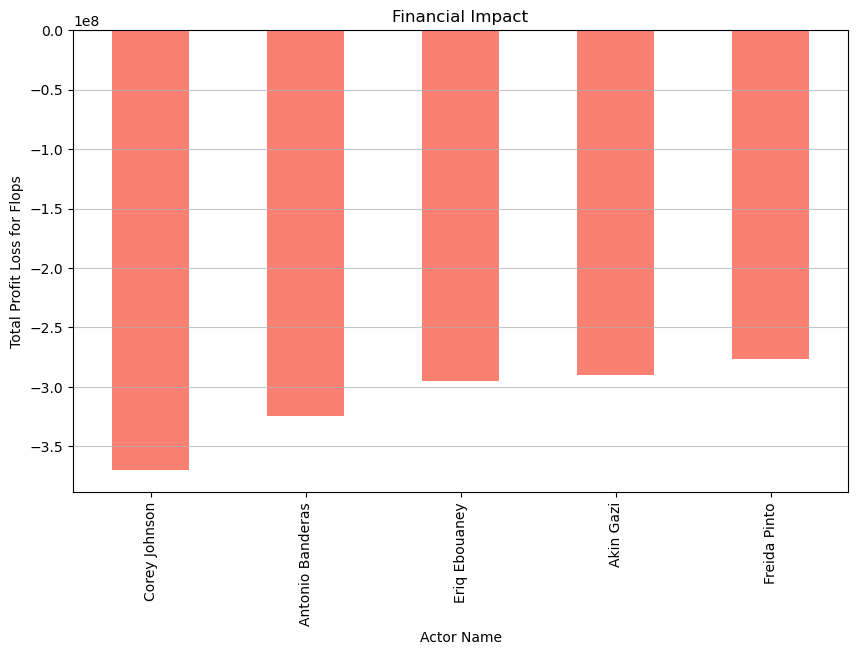

In [165]:
#create a side by side visualization (line graph)? of money lost by the "top 5" cast and crew

actor_loss = bad_movies.groupby('actor_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
actor_loss.plot(kind='bar', color='salmon')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Actor Name')
plt.grid(axis='y', alpha=0.7)

plt.show()



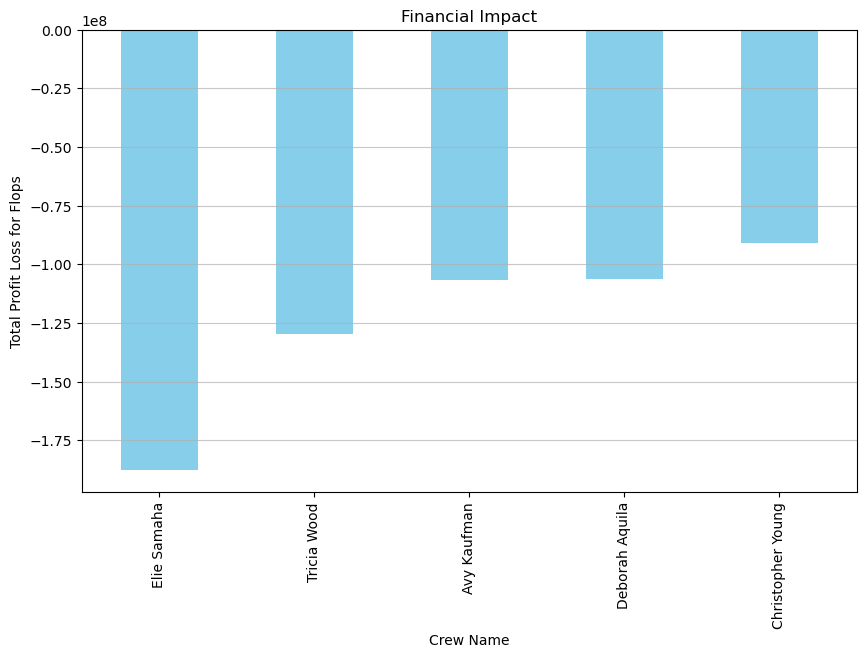

In [166]:
crew_loss = bad_movies_crew.groupby('crew_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
crew_loss.plot(kind='bar', color='skyblue')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Crew Name')
plt.grid(axis='y', alpha=0.7)

plt.show()